In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
dataset = pd.read_csv("../datasets/level_salary.csv")
dataset.columns = dataset.columns.str.strip()
dataset.head()


,Level,Salary
0,1.000000,60000
1,1.095477,62478
2,1.190955,65138
3,1.286432,67981
4,1.381910,71006


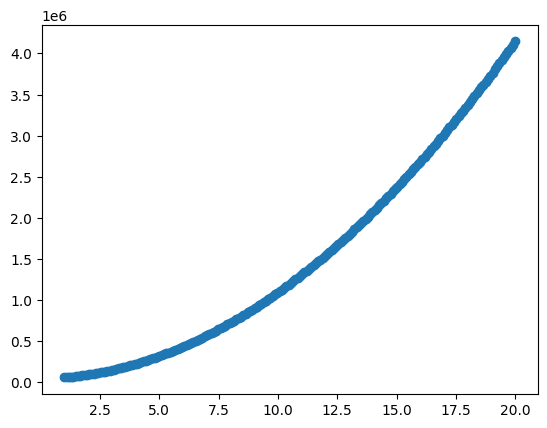

In [3]:
plt.scatter(dataset["Level"],dataset["Salary"])
plt.show()

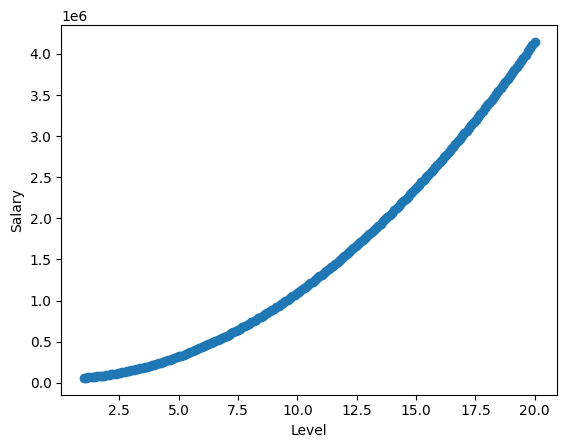

In [4]:
dataset.corr()
plt.scatter(dataset["Level"],dataset["Salary"])
plt.xlabel("Level")
plt.ylabel("Salary")
plt.show()

In [5]:
x= dataset[["Level"]]
y= dataset[["Salary"]]

In [6]:
pf = PolynomialFeatures(degree=2)
pf.fit(x)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [7]:
x = pf.transform(x)

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
lr.score(x_test,y_test)*100

99.99999999999291

In [16]:
lr.coef_

array([[    0.        ,  4999.98768366, 10000.00044412]])

In [17]:
lr.intercept_

array([44999.61364509])

In [11]:
prd = lr.predict(x)

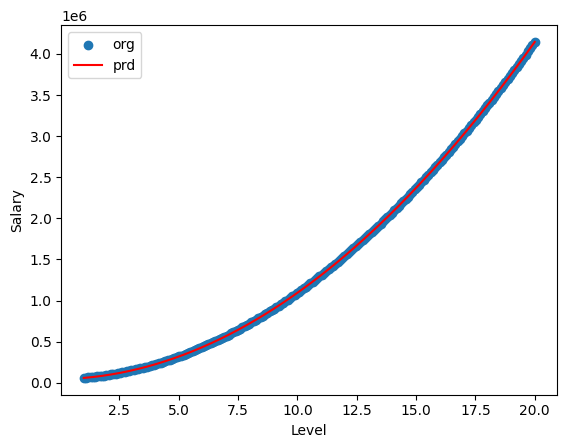

In [15]:
plt.scatter(dataset["Level"],dataset["Salary"])
plt.plot(dataset["Level"],prd,c="red")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.legend(["org","prd"])
plt.show()

In [22]:
test = pf.transform([[12]])
test

c:\Users\HP\Desktop\Projects\Machine Learning\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[  1.,  12., 144.]])

In [23]:
lr.predict(test)

array([[1544999.52980214]])